In [11]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import Estimator
from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import COBYLA
from qiskit.circuit.library import TwoLocal

Step 1: Define H₂ Hamiltonian (Manual)

In [12]:
hamiltonian = SparsePauliOp.from_list([
    ("II", -1.052373),
    ("ZI",  0.397937),
    ("IZ", -0.397937),
    ("ZZ", -0.011280),
    ("XX",  0.180931),
])

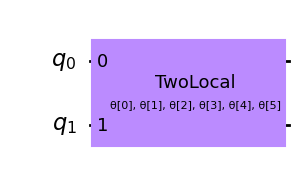

In [15]:
ansatz = TwoLocal(
    num_qubits=2,
    rotation_blocks="ry",
    entanglement_blocks="cx",
    reps=2
)

ansatz.draw("mpl")

In [24]:
optimizer = COBYLA(maxiter=300)

In [25]:
estimator = Estimator()

vqe = VQE(estimator, ansatz, optimizer)

result = vqe.compute_minimum_eigenvalue(hamiltonian)

print("Ground State Energy:", result.eigenvalue.real)

Ground State Energy: -1.8572740100902536


In [26]:
def callback(eval_count, params, mean, std):
    print(f"Step {eval_count}: Energy = {mean}")

vqe = VQE(estimator, ansatz, optimizer, callback=callback)

In [27]:
energies = []

def callback(eval_count, params, mean, std):
    energies.append(mean)
    print(f"Step {eval_count}: Energy = {mean:.6f}")

optimizer = COBYLA(maxiter=100)

vqe = VQE(
    estimator=estimator,
    ansatz=ansatz,
    optimizer=optimizer,
    callback=callback
)

result = vqe.compute_minimum_eigenvalue(hamiltonian)

print("Final Energy:", result.eigenvalue.real)

Step 1: Energy = -1.311212
Step 2: Energy = -1.152001
Step 3: Energy = -1.022164
Step 4: Energy = -1.338930
Step 5: Energy = -0.935313
Step 6: Energy = -1.001725
Step 7: Energy = -1.449110
Step 8: Energy = -1.663904
Step 9: Energy = -1.681291
Step 10: Energy = -1.599773
Step 11: Energy = -1.551067
Step 12: Energy = -1.533560
Step 13: Energy = -1.523301
Step 14: Energy = -1.687375
Step 15: Energy = -1.714806
Step 16: Energy = -1.609049
Step 17: Energy = -1.586802
Step 18: Energy = -1.799510
Step 19: Energy = -1.763440
Step 20: Energy = -1.773271
Step 21: Energy = -1.784208
Step 22: Energy = -1.723789
Step 23: Energy = -1.798222
Step 24: Energy = -1.848439
Step 25: Energy = -1.821446
Step 26: Energy = -1.847234
Step 27: Energy = -1.850078
Step 28: Energy = -1.851805
Step 29: Energy = -1.846274
Step 30: Energy = -1.847464
Step 31: Energy = -1.850183
Step 32: Energy = -1.850974
Step 33: Energy = -1.848463
Step 34: Energy = -1.844724
Step 35: Energy = -1.855232
Step 36: Energy = -1.855800
S

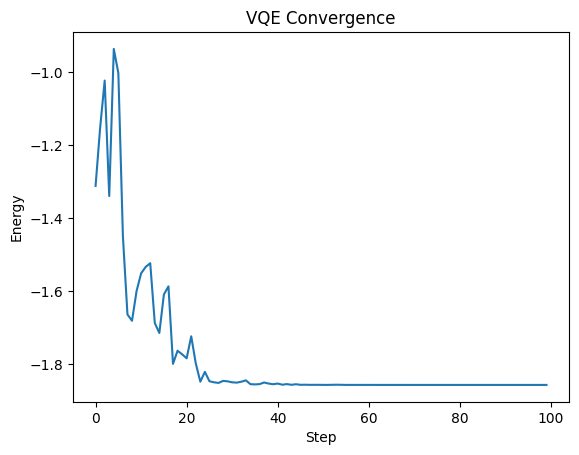

In [28]:
import matplotlib.pyplot as plt

plt.plot(energies)
plt.xlabel("Step")
plt.ylabel("Energy")
plt.title("VQE Convergence")
plt.show()